# Day 1 of Datavisualisation course.
- Lecture 01
- First day and some EDA(Exploratory Data analysis)
    - Same dataset as home_lectures/02_lecture
    - Good repetition

Tasks:
- Do initial EDA
- How many data jobs are there in the data set?             -   DONE
- How many work years are represented?                      -   DONE
- Which countries exists in this dataset?                   -   DONE
- What type of company sizes are there?                     -   DONE
- Ratio of remote work vs office                            -   DONE
- Average salaries per job role                             -   
- Median salaries per job role                              -   
- Seniority level and avarage salaries?                     -   
- Remote work and salaries?                                 -   
- Company location and avarage salaries                     -   
- Clean job titles -> from EX/SE/MID/EN                     -   
- Do different visualizations                               -   
- Export visualizations                                     -   
- Export cleaned data                                       -   

In [87]:
import pandas as pd
import duckdb

df = pd.read_csv("salaries_class_01.csv")
df.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [ ]:
# Steg 1, kolla vad som finns först, innehåller det några null values eller så.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           16534 non-null  int64
 1   experience_level    16534 non-null  str  
 2   employment_type     16534 non-null  str  
 3   job_title           16534 non-null  str  
 4   salary              16534 non-null  int64
 5   salary_currency     16534 non-null  str  
 6   salary_in_usd       16534 non-null  int64
 7   employee_residence  16534 non-null  str  
 8   remote_ratio        16534 non-null  int64
 9   company_location    16534 non-null  str  
 10  company_size        16534 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.4 MB


In [ ]:
# Dags att se över vilka kolumner som finns.
df.columns

In [ ]:
# Describe = Descriptive statistics. Beskrivande statistik.
# Describe visar endast de numeriska kolumnerna
df.describe().round(1)

,work_year,salary,salary_in_usd,remote_ratio
count,16534.0,16534.0,16534.0,16534.0
mean,2023.2,163727.0,149686.8,32.0
std,0.7,340205.7,68505.3,46.2
min,2020.0,14000.0,15000.0,0.0
25%,2023.0,101763.0,101125.0,0.0
50%,2023.0,142200.0,141300.0,0.0
75%,2024.0,187200.0,185900.0,100.0
max,2024.0,30400000.0,800000.0,100.0


In [ ]:
# transponering. Du flyttar på ordningen på rows <-> columns. Du byter plats på rader och columner för bättre läsbarhet.
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
work_year,16534.0,2023.2,0.7,2020.0,2023.0,2023.0,2024.0,2024.0
salary,16534.0,163727.0,340205.7,14000.0,101763.0,142200.0,187200.0,30400000.0
salary_in_usd,16534.0,149686.8,68505.3,15000.0,101125.0,141300.0,185900.0,800000.0
remote_ratio,16534.0,32.0,46.2,0.0,0.0,0.0,100.0,100.0


In [ ]:
# Se antal rader och columner
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 16534, Columns: 11


In [108]:
# Bra frågeställningar: Vad representerar en rad?
# I det här fallet är det en employee då det är employee_residence som avslöjar vad varje rad innebär.
df.head(3)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M


In [109]:
# Antal jobb som finns i datasettet.
print(f"Number of employees in this dataset is: {len(df)}")

Number of employees in this dataset is: 16534


In [ ]:
# Utforska olika 'categorical' columns. Olika kolumn kategorier
# T.ex - experience_level, employment_type, job_title, employee_residence, remote_ratio.
df["experience_level"].value_counts()

experience_level
SE    10670
MI     4038
EN     1325
EX      501
Name: count, dtype: int64

<Axes: xlabel='experience_level'>

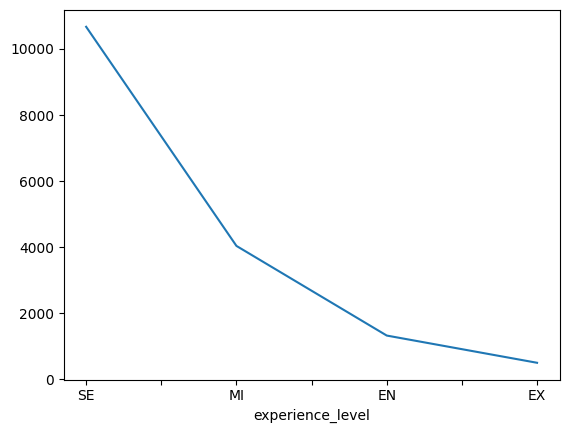

In [ ]:
# Plottar du så här blir det helt skevt.
df["experience_level"].value_counts().plot()

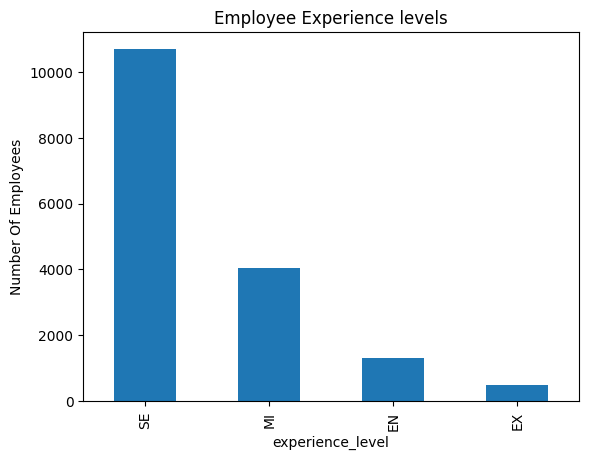

In [ ]:
# df["experience_level"].value_counts().plot.bar()

# .plot() wraps around matplotlib and returns an Axes instance
ax = (
    df["experience_level"]
    .value_counts()
    .plot(
        kind="bar",
        ylabel="Number Of Employees",
        title="Employee Experience levels",
    )
)

In [139]:
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("employees_seniority.lvl.png", dpi=200)

## Data cleaning with Pandas.
- Some titles are the same job, the title only differs within the title name.
    - Example: Data scientist and data science are the same in this example.

In [158]:
import duckdb

duckdb.sql("""---sql
FROM df
WHERE job_title ILIKE 'data scien%'      
           
""").df()["job_title"].value_counts()

job_title
Data Scientist               3314
Data Science                  271
Data Science Manager          122
Data Science Consultant        83
Data Science Engineer          29
Data Science Lead              26
Data Science Practitioner      16
Data Science Director           8
Data Science Analyst            4
Data Scientist Lead             2
Data Science Tech Lead          1
Name: count, dtype: int64

In [160]:
duckdb.sql("""--sql
SELECT 
    * EXCLUDE(job_title),
        CASE
           WHEN job_title ILIKE 'data_scien%' THEN 'Data Scientist'
           ELSE job_title
        END AS job_title
FROM df

""").df()["job_title"].value_counts()

job_title
Data Scientist               3876
Data Engineer                3464
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
BI Data Engineer                1
Deep Learning Researcher        1
Marketing Data Engineer         1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 145, dtype: int64

In [ ]:
df["job_title"].value_counts()

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
Deep Learning Researcher        1
Marketing Data Engineer         1
Data Science Tech Lead          1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 155, dtype: int64

In [110]:
# Antal unika job titlar
df["job_title"].nunique()

155

In [ ]:
# How many data jobs are there in the data set?
# Find out how many total "data" jobs there are.

# 1. Låt DuckDB göra jobbet och bara returnera summan
query = """
    SELECT COUNT(*) AS total_data_jobs
    FROM df
    WHERE job_title ILIKE 'data%'
    """
# 2. Hämta resultattabellen till Pandas
result_df = duckdb.sql(query).df()

# 3. Plocka ut den faktiska siffran från tabellen
total_jobs = result_df["total_data_jobs"].iloc[0]

print(f"Totalt antal jobb som innehåller 'data' i sig: {total_jobs}")

Totalt antal jobb som innehåller 'data' i sig: 11038


In [4]:
# Work years represented:

df["work_year"].value_counts()

work_year
2023    8519
2024    6067
2022    1655
2021     218
2020      75
Name: count, dtype: int64

In [ ]:
# Which countries exists in this dataset?


company_countries = df["company_location"].unique()
resident_countries = df["employee_residence"].unique()

set_company = set(company_countries)
set_resident = set(resident_countries)

all_unique_countries = set_company | set_resident

print(f"Totalt antal unika länder i datasettet: {len(all_unique_countries)}")
print(f"Länderna är:  {sorted(all_unique_countries)}")


Totalt antal unika länder i datasettet: 90
Länderna är:  ['AD', 'AE', 'AM', 'AR', 'AS', 'AT', 'AU', 'BA', 'BE', 'BG', 'BO', 'BR', 'BS', 'CA', 'CF', 'CH', 'CL', 'CN', 'CO', 'CR', 'CY', 'CZ', 'DE', 'DK', 'DO', 'DZ', 'EC', 'EE', 'EG', 'ES', 'FI', 'FR', 'GB', 'GE', 'GH', 'GI', 'GR', 'HK', 'HN', 'HR', 'HU', 'ID', 'IE', 'IL', 'IN', 'IQ', 'IR', 'IT', 'JE', 'JP', 'KE', 'KR', 'KW', 'LB', 'LT', 'LU', 'LV', 'MD', 'MT', 'MU', 'MX', 'MY', 'NG', 'NL', 'NO', 'NZ', 'OM', 'PE', 'PH', 'PK', 'PL', 'PR', 'PT', 'QA', 'RO', 'RS', 'RU', 'SA', 'SE', 'SG', 'SI', 'TH', 'TN', 'TR', 'UA', 'UG', 'US', 'UZ', 'VN', 'ZA']


In [ ]:
df["company_size"].value_counts().sort_index(ascending=True)

company_size
L     1040
M    15306
S      188
Name: count, dtype: int64

In [ ]:
# What type of company sizes are there?

company_sizes = df["company_size"].unique()
company_size = set(company_sizes)
print(f"There are these types of companies: {company_size}")


There are these types of companies: {'L', 'S', 'M'}


In [ ]:
# Ratio of remote work vs office

df["remote_ratio"].value_counts()

remote_ratio
0      11118
100     5167
50       249
Name: count, dtype: int64

In [ ]:
# Räkna ut ratio.
# (Antal i en grupp) / (Totalt antal rader) = Ratio
ratio = df["remote_ratio"].value_counts(normalize=True) * 100

ratio_rounded = ratio.round(1)
print(ratio)

print(f"cleaned and prettier ratio: {ratio_rounded}")

remote_ratio
0      67.243256
100    31.250756
50      1.505988
Name: proportion, dtype: float64
cleaned and prettier ratio: remote_ratio
0      67.2
100    31.3
50      1.5
Name: proportion, dtype: float64
